Introduction & Clinical Context

Cardiovascular disease risk emerges from the interaction of metabolic, renal, and hemodynamic dysfunction rather than from a single isolated factor. Contemporary risk equations, such as the American Heart Association PREVENT™ framework, represent an important step toward integrated risk assessment but remain fixed, population-level models that summarize risk without revealing the biological pathways driving it.

In real-world clinical practice, patients with similar calculated risk scores often differ substantially in their underlying cardiometabolic profiles. Some exhibit early glycemic or renal abnormalities despite normal body mass index or blood pressure, while others show predominantly hemodynamic risk—patterns that can delay recognition of high-risk trajectories when traditional thresholds are applied.

This analysis applies unsupervised learning to real, de-identified NHANES data to identify latent Cardiovascular-Kidney-Metabolic (CKM) phenotypes using a transparent, NumPy-based K-Means clustering approach. By grouping individuals according to shared biological profiles rather than predefined risk equations, this framework enables interpretable phenotyping that may support earlier and more targeted prevention strategies. Because clustering is inherently adaptive, phenotypic structures can evolve across successive NHANES survey cycles, supporting a precision public health approach responsive to changes in population biology and environment.

Data Source and Reproducibility

This analysis uses raw, publicly available data from the NHANES 2017–March 2020 pre-pandemic cycle, obtained directly from the U.S. Centers for Disease Control and Prevention (CDC). NHANES data are distributed across multiple survey modules, including demographics, physical examination, and laboratory measurements, which were merged at the participant level using the unique identifier SEQN.

All data integration, clinical feature engineering, and preprocessing are performed from scratch in this notebook to ensure methodological transparency and clinical integrity. In particular, kidney function is derived from serum creatinine using the CKD-EPI (2021) equation, and blood pressure is summarized from multiple oscillometric measurements. All downstream cleaning decisions—including missingness handling, physiologic plausibility filtering, and feature normalization—are explicitly documented and implemented.

Because the objective of this analysis is phenotype discovery rather than estimation of national prevalence, NHANES survey weights are not applied during clustering. Results are interpreted as data-driven subgroup patterns within the analytic cohort rather than population-level prevalence estimates.

More recent NHANES releases (2021–2023) were not used due to substantial pandemic-related disruptions in data collection, including lower response rates and modified sampling strategies that increase the risk of nonresponse bias. The 2017–March 2020 pre-pandemic cycle preserves NHANES’s traditional oversampling framework and provides a stable, representative baseline population that is conceptually aligned with contemporary Cardiovascular-Kidney-Metabolic (CKM) risk frameworks, including the AHA PREVENT™ equations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
demo = pd.read_sas("data/raw/P_DEMO.xpt", format="xport")
bmx  = pd.read_sas("data/raw/P_BMX.xpt",  format="xport")
bpxo  = pd.read_sas("data/raw/P_BPXO.xpt",  format="xport")
ghb  = pd.read_sas("data/raw/P_GHB.xpt",  format="xport")
bio  = pd.read_sas("data/raw/P_BIOPRO.xpt", format="xport")

# 1) Merge: keep provenance (left joins)
df = (demo
      .merge(bmx,  on="SEQN", how="left")
      .merge(bpxo, on="SEQN", how="left")   # oscillometric BP file
      .merge(ghb,  on="SEQN", how="left")
      .merge(bio,  on="SEQN", how="left"))

print("Merged (provenance) shape:", df.shape)

Merged (provenance) shape: (15560, 102)


"Keeping provenance"

NHANES data are collected in stages. All participants complete the interview (demographics), but only a subset attend the Mobile Examination Center where physical measurements and laboratory tests are performed. As a result, some individuals have complete cardiometabolic data while others are missing one or more biomarkers.

Left joins were used when merging NHANES modules to preserve provenance, meaning we retain the full set of interviewed participants from the demographic file and explicitly track which measurements are missing at later stages. This approach allows us to transparently quantify data attrition and missingness rather than silently excluding participants during the merge step.

Instead of implicitly dropping individuals via inner joins, the analytic cohort was defined after merging by requiring non-missing values for the specific Cardiovascular–Kidney–Metabolic (CKM) features used in clustering. This separation between data integration and cohort definition improves reproducibility, supports clear reporting of inclusion criteria, and avoids unintended selection bias introduced during merging.

In [3]:
# Engineer BP from repeated measures
df["SBP"] = df[["BPXOSY1","BPXOSY2","BPXOSY3"]].mean(axis=1)
df["DBP"] = df[["BPXODI1","BPXODI2","BPXODI3"]].mean(axis=1)

# Subset + rename core CKM variables
cols = {
    "SEQN": "ID",
    "RIDAGEYR": "Age",
    "RIAGENDR": "Sex_Code",
    "BMXBMI": "BMI",
    "SBP": "Systolic_BP",
    "DBP": "Diastolic_BP",
    "LBXGH": "HbA1c",
    "LBXSCR": "Creatinine",
    "LBXSTR": "Triglycerides",   # ✅ chosen
}

df_final = df[list(cols.keys())].rename(columns=cols)
print("df_final shape (before complete-case):", df_final.shape)

df_final shape (before complete-case): (15560, 9)


Blood Pressure Processing

NHANES blood pressure measurements are collected using an oscillometric device and recorded as multiple repeated readings for each participant within a single examination session. Specifically, up to three systolic and diastolic measurements are available (BPXOSY1–3 and BPXODI1–3).

To obtain a single, clinically meaningful blood pressure value per participant, the available systolic and diastolic readings were averaged. This approach reduces measurement noise from individual readings and aligns with standard clinical and epidemiologic practice when multiple blood pressure measurements are available.

The resulting mean systolic and diastolic blood pressure values were used as inputs for downstream feature engineering and clustering.

In [4]:
df_final.isna().mean().sort_values(ascending=False)

Triglycerides    0.391195
Creatinine       0.391067
HbA1c            0.374229
Systolic_BP      0.334640
Diastolic_BP     0.334640
BMI              0.155720
ID               0.000000
Age              0.000000
Sex_Code         0.000000
dtype: float64

Missingness Assessment

The proportion of missing values for each CKM variable was quantified after data integration. As expected in NHANES, laboratory and examination-based measurements exhibit higher missingness than interview-derived variables, reflecting study design rather than data quality issues.
These results informed the definition of a complete-case analytic cohort for clustering, as distance-based methods such as K-Means cannot operate on missing values. Participants are retained only if all CKM variables required for phenotyping are present. This approach ensures that clustering is performed on complete, observed biological profiles rather than heavily imputed values, preserving interpretability of the resulting phenotypes.

In [5]:
# Physiologic Plausibility Filtering
before = len(df_final)

plausible = (
    (df_final["Age"] >= 18) &
    (df_final["BMI"].between(10, 100)) &
    (df_final["Systolic_BP"].between(60, 250)) &
    (df_final["Diastolic_BP"].between(40, 150)) &
    (df_final["Creatinine"] > 0) &
    (df_final["HbA1c"] > 0) &
    (df_final["Triglycerides"] > 0)
)

df_plausible = df_final.loc[plausible].copy()
after = len(df_plausible)

print(f"Plausible cohort: {after} / {before} ({after/before:.1%})")


Plausible cohort: 7392 / 15560 (47.5%)


To reduce noise from non-biological values, conservative physiologic plausibility filters were applied to key CKM variables

In [6]:
required = [
    "Age",
    "Sex_Code",
    "BMI",
    "Systolic_BP",
    "Diastolic_BP",
    "HbA1c",
    "Creatinine",
    "Triglycerides",
]

before = len(df_plausible)
df_ckm = df_plausible.dropna(subset=required).copy()
after = len(df_ckm)

print(f"Analytic CKM cohort: {after} / {before} ({after/before:.1%})")

Analytic CKM cohort: 7392 / 7392 (100.0%)


After physiologic plausibility filtering, the analytic cohort was defined by retaining participants with complete data for all CKM features required for clustering. This ensures that distance-based modeling is performed on fully observed clinical profiles.

In [7]:
def calculate_egfr_ckdepi_2021(creatinine_mg_dl, age_years, sex_code):
    """
    CKD-EPI (2021) creatinine-based eGFR (race-free).
    sex_code: NHANES RIAGENDR style (1=Male, 2=Female)
    Returns eGFR in mL/min/1.73m^2.
    """
    creatinine = np.asarray(creatinine_mg_dl, dtype=float)
    age = np.asarray(age_years, dtype=float)

    is_female = (np.asarray(sex_code) == 2)

    kappa = np.where(is_female, 0.7, 0.9)
    alpha = np.where(is_female, -0.241, -0.302)
    sex_mult = np.where(is_female, 1.012, 1.0)

    scr_kappa = creatinine / kappa

    egfr = (
        142
        * (np.minimum(scr_kappa, 1) ** alpha)
        * (np.maximum(scr_kappa, 1) ** -1.200)
        * (0.9938 ** age)
        * sex_mult
    )
    return egfr

# Compute eGFR and add to analytic cohort
df_ckm["eGFR"] = calculate_egfr_ckdepi_2021(
    creatinine_mg_dl=df_ckm["Creatinine"].values,
    age_years=df_ckm["Age"].values,
    sex_code=df_ckm["Sex_Code"].values
)

# Quick sanity check
df_ckm["eGFR"].describe()


count    7392.000000
mean       94.894477
std        22.707699
min         2.958234
25%        80.418454
50%        97.492862
75%       111.567825
max       163.587129
Name: eGFR, dtype: float64

eGFR is an estimated measure of kidney function derived from serum creatinine, age, and sex. The eGFR was computed using the CKD-EPI 2021 equation to incorporate renal function into CKM phenotyping as a clinically interpretable feature. The eGFR distribution looks clinically sane and ready for use.

In [8]:
# Mean Arterial Pressure (MAP)
df_ckm["MAP"] = (2 * df_ckm["Diastolic_BP"] + df_ckm["Systolic_BP"]) / 3
df_ckm["MAP"].describe()

count    7392.000000
mean       90.851281
std        12.558888
min        53.777778
25%        82.000000
50%        89.666667
75%        98.444444
max       159.777778
Name: MAP, dtype: float64

Mean arterial pressure (MAP) was calculated to summarize hemodynamic load using both systolic and diastolic blood pressure, providing a single, clinically interpretable measure of vascular pressure relevant to cardiovascular risk.

In [9]:
cluster_features = [
    "Age",
    "BMI",
    "HbA1c",
    "Triglycerides",
    "MAP",
    "eGFR",
]

X = df_ckm[cluster_features].values
X.shape


(7392, 6)

A feature matrix was constructed from the selected CKM variables and used as input for unsupervised clustering.

In [10]:
# Check the clustering matrix contains no missing values
assert not np.isnan(X).any(), "NaNs present in clustering matrix"

A sanity check was included to ensure the clustering matrix contains no missing values, as K-Means requires fully observed inputs.

In [11]:
# Compute feature-wise mean and standard deviation
mu = X.mean(axis=0)
sigma = X.std(axis=0)

# Z-score normalization
X_norm = (X - mu) / sigma

X_norm.shape

(7392, 6)

The data features are on different scales (years, mg/dL, mmHg, mL/min); therefore, all continuous features were standardized using z-score normalization prior to clustering to ensure balanced Euclidean distance calculations.

In [12]:
def assign_clusters(X, centroids):
    """E-step: assign each row to the nearest centroid (Euclidean distance)."""
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)  # (N,K)
    return np.argmin(distances, axis=1)

def update_centroids(X, assignments, K):
    """M-step: recompute centroids as the mean of assigned points."""
    M = X.shape[1]
    centroids = np.zeros((K, M))
    for k in range(K):
        mask = (assignments == k)
        if np.any(mask):
            centroids[k] = X[mask].mean(axis=0)
        else:
            # Empty cluster: reinitialize to a random data point
            centroids[k] = X[np.random.randint(0, X.shape[0])]
    return centroids

def run_kmeans_pp(X, K, max_iters=200, tol=1e-4, seed=42):
    """
    NumPy K-Means with k-means++ initialization.
    """
    centroids = kmeans_pp_init(X, K, seed=seed)

    for i in range(max_iters):
        old = centroids.copy()

        assignments = assign_clusters(X, centroids)
        centroids = update_centroids(X, assignments, K)

        shift = np.linalg.norm(centroids - old, axis=1).sum()
        if shift < tol:
            return centroids, assignments, i + 1, shift

    return centroids, assignments, max_iters, shift

def inertia(X, centroids, assignments):
    """Within-cluster sum of squares (WCSS / inertia)."""
    diffs = X - centroids[assignments]
    return np.sum(diffs ** 2)


K-means clustering was implemented from scratch using Numpy to ensure full transparency of distance computations and centroids updates.

In [13]:
def kmeans_pp_init(X, K, seed=42):
    """
    k-means++ initialization.
    X: (N, M) normalized data
    K: number of clusters
    """
    rng = np.random.default_rng(seed)
    N = X.shape[0]

    # Choose first centroid uniformly at random
    centroids = [X[rng.integers(0, N)]]

    # Choose remaining centroids
    for _ in range(1, K):
        # Compute squared distance to nearest existing centroid
        dists_sq = np.min(
            np.linalg.norm(X[:, None, :] - np.array(centroids)[None, :, :], axis=2) ** 2,
            axis=1
        )

        # Probability proportional to distance squared
        probs = dists_sq / dists_sq.sum()
        next_idx = rng.choice(N, p=probs)
        centroids.append(X[next_idx])

    return np.array(centroids)

Random initialization can place centroids too close together, leading to slower convergence or poorer local minima. k-means++ initialization was used to select initial centroids that are well separated in feature space, improving convergence stability and reducing sensitivity to random starts. The same assignment and centroid update steps were used for all models; only the centroid initialization strategy was changed from random selection to k-means++.

In [14]:
Ks = range(2, 11)
inertias = []
iters_used = []

for K in Ks:
    C, a, iters, shift = run_kmeans_pp(X_norm, K=K, seed=42)
    inertias.append(inertia(X_norm, C, a))
    iters_used.append(iters)

list(zip(Ks, inertias, iters_used))

[(2, np.float64(33882.086995821235), 13),
 (3, np.float64(29617.439398640294), 16),
 (4, np.float64(25932.167062442506), 27),
 (5, np.float64(23677.597334603237), 49),
 (6, np.float64(21343.52265336711), 61),
 (7, np.float64(19920.7519150119), 30),
 (8, np.float64(18886.23917754081), 74),
 (9, np.float64(17746.83743594816), 67),
 (10, np.float64(17026.175771051487), 45)]

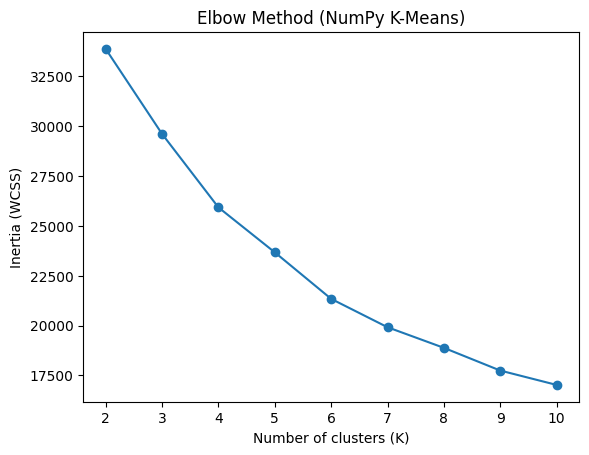

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method (NumPy K-Means)")
plt.show()

In [16]:
list(zip(Ks, inertias))

[(2, np.float64(33882.086995821235)),
 (3, np.float64(29617.439398640294)),
 (4, np.float64(25932.167062442506)),
 (5, np.float64(23677.597334603237)),
 (6, np.float64(21343.52265336711)),
 (7, np.float64(19920.7519150119)),
 (8, np.float64(18886.23917754081)),
 (9, np.float64(17746.83743594816)),
 (10, np.float64(17026.175771051487))]

To guide selection of the number of clusters, K-Means was fit across K = 2–10 and within-cluster sum of squares (inertia) was examined. While inertia decreased monotonically with increasing K, a relative flattening of the curve was observed after K = 6. Accordingly, K = 6 was selected to balance model fit with clinical interpretability, capturing meaningful CKM heterogeneity without over-fragmenting phenotypes.

In [17]:
K = 6
centroids_norm, assignments, iters, final_shift = run_kmeans_pp(
    X_norm, K=K, seed=42
)

print(f"K={K} converged in {iters} iterations (final shift={final_shift:.6f})")

# Cluster sizes
unique, counts = np.unique(assignments, return_counts=True)
dict(zip(unique, counts))

K=6 converged in 61 iterations (final shift=0.000000)


{np.int64(0): np.int64(989),
 np.int64(1): np.int64(2334),
 np.int64(2): np.int64(1902),
 np.int64(3): np.int64(329),
 np.int64(4): np.int64(267),
 np.int64(5): np.int64(1571)}

In [18]:
# Back-transform centroids to original units
centroids_raw = centroids_norm * sigma + mu

centroid_table = pd.DataFrame(
    centroids_raw,
    columns=cluster_features
)
centroid_table.index.name = "Cluster"
centroid_table


,Age,BMI,HbA1c,Triglycerides,MAP,eGFR
Cluster,,,,,,
0,41.928210,42.257230,5.752376,139.115268,91.815358,103.053909
1,31.620394,25.847901,5.288946,101.464010,82.751285,112.629146
2,67.204522,28.538854,5.877077,128.022082,86.954434,73.995924
3,59.592705,32.972948,9.827052,188.158055,93.342790,88.329655
4,47.374532,31.297753,5.947940,484.588015,94.005618,97.453781
5,57.213877,29.035073,5.783132,130.918523,105.938362,89.651412


Cluster centroids were transformed back to original clinical units to support direct clinical interpretation of CKM phenotypes.

In [19]:
# Attach cluster labels to the dataset
df_ckm = df_ckm.copy()
df_ckm["cluster"] = assignments
df_ckm["cluster"].value_counts().sort_index()

cluster
0     989
1    2334
2    1902
3     329
4     267
5    1571
Name: count, dtype: int64

Because triglycerides exhibited a highly right-skewed distribution, a sensitivity analysis using log-transformed triglyceride values was performed. The lipid-dominant phenotype remained identifiable, indicating that this cluster reflects a biologically meaningful subgroup rather than an artifact of extreme values.

In [20]:
# Create a transformed copy
df_ckm_sens = df_ckm.copy()
df_ckm_sens["Triglycerides_log"] = np.log(df_ckm_sens["Triglycerides"])

In [21]:
# Sensitivity clustering features (log-transformed TG)
cluster_features_sens = [
    "Age",
    "BMI",
    "HbA1c",
    "Triglycerides_log",
    "MAP",
    "eGFR",
]

# Build feature matrix
X_sens = df_ckm_sens[cluster_features_sens].values

# Z-score normalization
mu_sens = X_sens.mean(axis=0)
sigma_sens = X_sens.std(axis=0)
X_sens_norm = (X_sens - mu_sens) / sigma_sens

# Sanity check: no missing values
assert not np.isnan(X_sens_norm).any(), "NaNs present in sensitivity clustering matrix"

# Refit K-Means++ (K = 6)
centroids_sens_norm, assignments_sens, _, _ = run_kmeans_pp(
    X_sens_norm, K=6, seed=42
)

In [22]:
df_compare = df_ckm.copy()
df_compare["cluster_orig"] = assignments
df_compare["cluster_sens"] = assignments_sens

ct = pd.crosstab(
    df_compare["cluster_orig"],
    df_compare["cluster_sens"],
    normalize="index"
)

ct

cluster_sens,0,1,2,3,4,5
cluster_orig,,,,,,
0,0.000000,0.038423,0.761375,0.005056,0.003033,0.192113
1,0.000000,0.814053,0.000000,0.002142,0.000000,0.183805
2,0.000526,0.018402,0.000526,0.874343,0.052576,0.053628
3,0.969605,0.000000,0.006079,0.012158,0.006079,0.006079
4,0.048689,0.000000,0.018727,0.059925,0.014981,0.857678
5,0.003819,0.020369,0.003819,0.009548,0.789306,0.173138


A sensitivity analysis using log-transformed triglycerides produced a highly concordant clustering structure, with the lipid-dominant phenotype remaining clearly identifiable, indicating robustness to triglyceride skewness.

Results
In summary, six distinct Cardiovascular–Kidney–Metabolic phenotypes emerged. These included a metabolically healthy reference group, an obesity-dominant phenotype with preserved renal function, an age-associated kidney-first phenotype, a blood-pressure–dominant phenotype, a lipid-dominant metabolic phenotype, and a severe metabolic phenotype characterized by marked dysglycemia. Together, these findings illustrate multiple biologically distinct pathways to cardiovascular risk that are not captured by single-variable thresholds.

In [23]:
centroid_table

,Age,BMI,HbA1c,Triglycerides,MAP,eGFR
Cluster,,,,,,
0,41.928210,42.257230,5.752376,139.115268,91.815358,103.053909
1,31.620394,25.847901,5.288946,101.464010,82.751285,112.629146
2,67.204522,28.538854,5.877077,128.022082,86.954434,73.995924
3,59.592705,32.972948,9.827052,188.158055,93.342790,88.329655
4,47.374532,31.297753,5.947940,484.588015,94.005618,97.453781
5,57.213877,29.035073,5.783132,130.918523,105.938362,89.651412


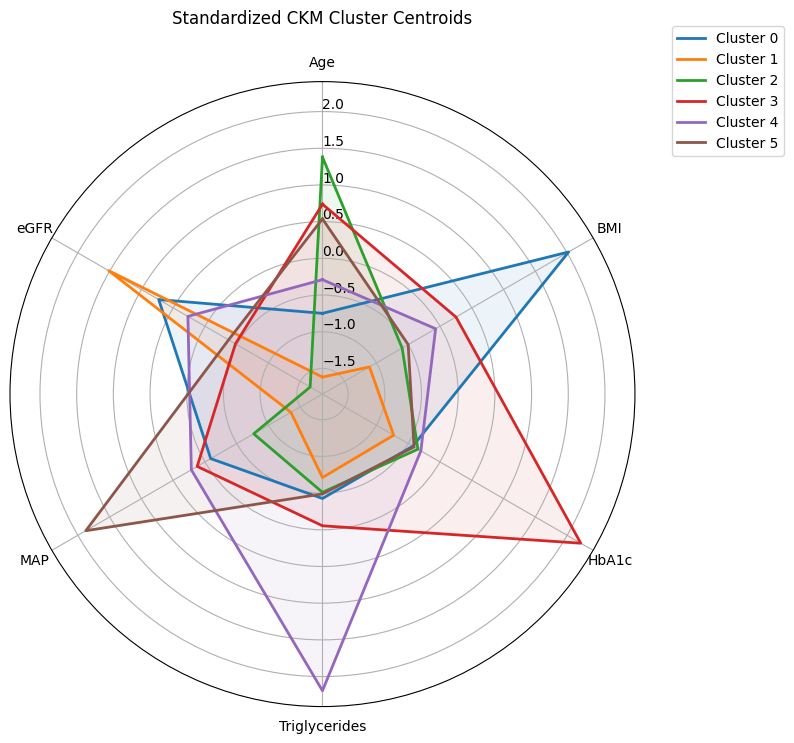

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def radar_plot_cluster_centroids_labeled(
    centroids_df,
    features=("Age", "BMI", "HbA1c", "Triglycerides", "MAP", "eGFR"),
    title="Standardized CKM Cluster Centroids",
    colors=None,          # optional list of hex colors, length >= #clusters
    show_legend=False     # legend not needed if labels are on-plot
):
    # 1) Select features in desired order
    C = centroids_df.loc[:, list(features)].copy()

    # 2) Standardize across clusters (z-score per feature) for visualization only
    Z = (C - C.mean(axis=0)) / C.std(axis=0, ddof=0)

    labels = list(features)
    N = len(labels)

    # Angles around the circle
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close loop

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    # Put first axis at the top, go clockwise
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    # Choose colors (default: matplotlib cycle) or your palette
    cluster_ids = list(Z.index)
    if colors is not None:
        if len(colors) < len(cluster_ids):
            raise ValueError(f"Need at least {len(cluster_ids)} colors, got {len(colors)}.")
        color_map = {cid: colors[i] for i, cid in enumerate(cluster_ids)}
    else:
        # fallback to matplotlib default cycle
        cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
        if len(cycle) < len(cluster_ids):
            # repeat if needed (rare)
            cycle = (cycle * (len(cluster_ids) // max(1, len(cycle)) + 1))[:len(cluster_ids)]
        color_map = {cid: cycle[i] for i, cid in enumerate(cluster_ids)}

    # 3) Plot each cluster + add direct label
    for cid in cluster_ids:
        vals = Z.loc[cid].tolist()
        vals += vals[:1]  # close loop

        col = color_map[cid]
        ax.plot(angles, vals, linewidth=2, color=col)
        ax.fill(angles, vals, alpha=0.08, color=col)

        # --- Direct label placement ---
        # Place label near the feature where this cluster is highest (most "peaked")
        vals_no_close = np.array(Z.loc[cid].tolist())
        peak_idx = int(np.argmax(vals_no_close))
        peak_angle = angles[peak_idx]
        peak_radius = vals_no_close[peak_idx]

        # Add a small outward offset so label isn't on top of the line
        r_offset = 0.18
        ax.text(
            peak_angle,
            peak_radius + r_offset,
            f"Cluster {cid}",
            fontsize=10,
            ha="center",
            va="center",
            color=col,
            fontweight="bold"
        )

    ax.set_title(title, y=1.08)
    if show_legend:
        ax.legend([f"Cluster {cid}" for cid in cluster_ids], loc="upper right", bbox_to_anchor=(1.25, 1.10))

    plt.tight_layout()
    plt.show()

radar_plot_cluster_centroids(
    centroids_df=centroid_table,
    features=("Age", "BMI", "HbA1c", "Triglycerides", "MAP", "eGFR"),
    title="Standardized CKM Cluster Centroids"
)
